In [605]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [606]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [607]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 6607
Columns: 20


In [608]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [609]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [610]:
df.duplicated().sum()

np.int64(0)

In [611]:
# Missing values check before cleaning

print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [612]:
# Fill missing categorical values with Mode

df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df[
    "Parental_Education_Level"
].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df[
    "Distance_from_Home"
].fillna(
    df["Distance_from_Home"].mode()[0]
)

In [613]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [614]:
df.to_csv(
    "../data/cleaned_student_data.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [615]:
# ==========================
# Exploratory Data Analysis
# ==========================

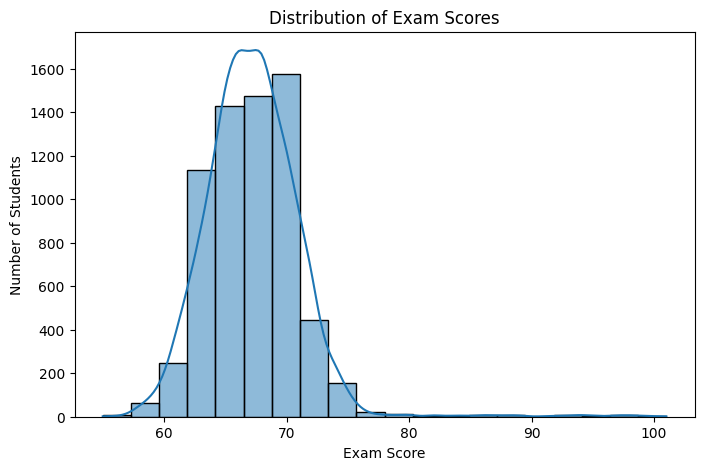

In [616]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")


plt.savefig(
    "../images/distribution_of_exam_scores.png",
       bbox_inches="tight"
)

plt.show()


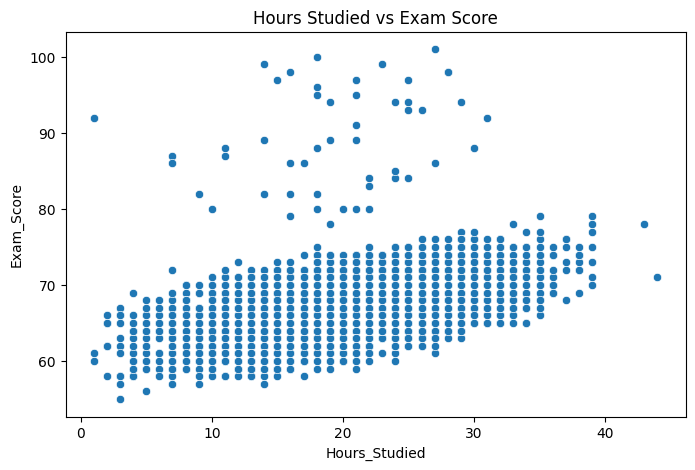

In [617]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=df
)

plt.title("Hours Studied vs Exam Score")

plt.savefig(
    "../images/Hours Studied vs Exam Score.png",
         bbox_inches="tight"
 )

plt.show()



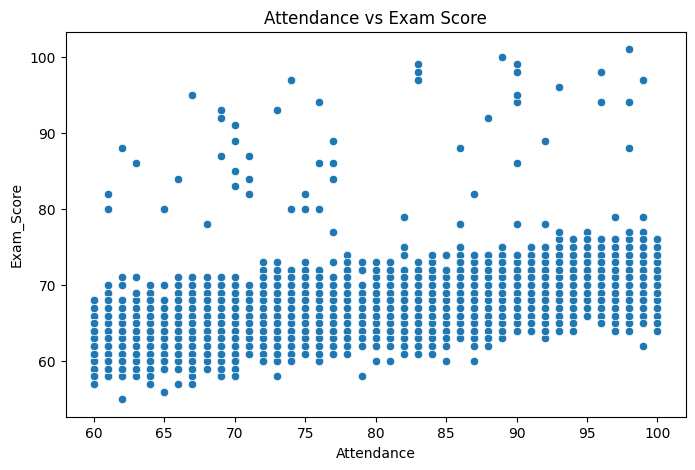

In [618]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Attendance",
    y="Exam_Score",
    data=df
)

plt.title("Attendance vs Exam Score")


plt.savefig(
    "../images/Attendance vs Exam Score.png",
         bbox_inches="tight"
)

plt.show()


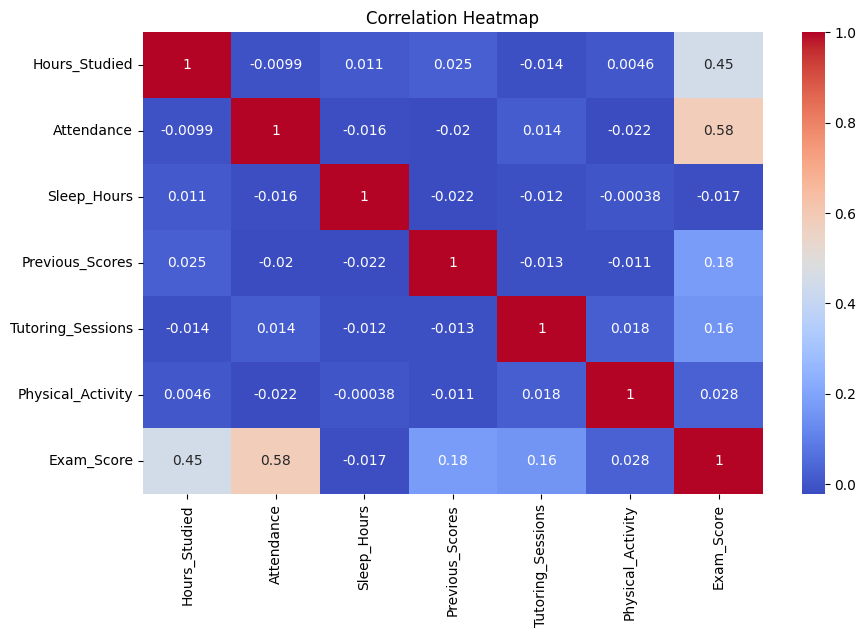

In [619]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/Correlation Heatmap.png",
         bbox_inches="tight"
)
plt.show()


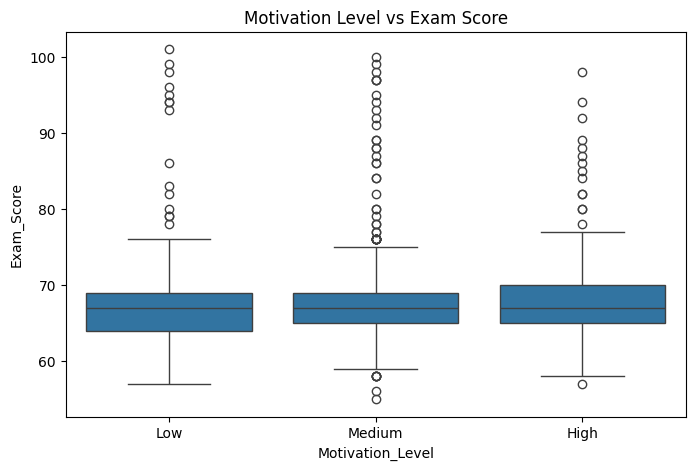

In [620]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Motivation_Level",
    y="Exam_Score",
    data=df
)

plt.title("Motivation Level vs Exam Score")

plt.savefig(
    "../images/Motivation vs Exam Score.png",
         bbox_inches="tight"
)

plt.show()



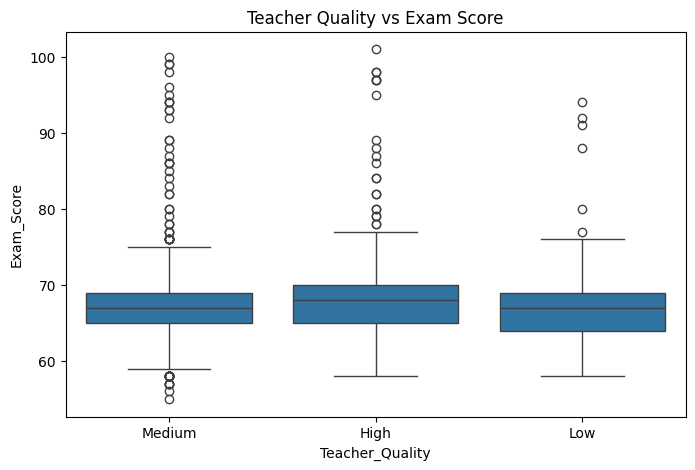

In [621]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Teacher_Quality",
    y="Exam_Score",
    data=df
)

plt.title("Teacher Quality vs Exam Score")


plt.savefig(
    "../images/Teacher Quality vs Exam Score.png",
         bbox_inches="tight"
)

plt.show()


In [622]:
data = df.copy()

data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [623]:
# Model 1: Linear Regression (Final Selected Model)

In [624]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include="object").columns:
    data[col] = le.fit_transform(data[col])

data.head()

C:\Users\Vanshikha\AppData\Local\Temp\ipykernel_22404\2427168443.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include="object").columns:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [625]:
X = data.drop("Exam_Score", axis=1)

y = data["Exam_Score"]

print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


In [626]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5285, 19)
(1322, 19)


In [627]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

In [628]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:",
      mean_absolute_error(y_test, predictions))

print("MSE:",
      mean_squared_error(y_test, predictions))

print("R2 Score:",
      r2_score(y_test, predictions))

MAE: 1.0155490830845968
MSE: 4.399275539170952
R2 Score: 0.6887688020307758


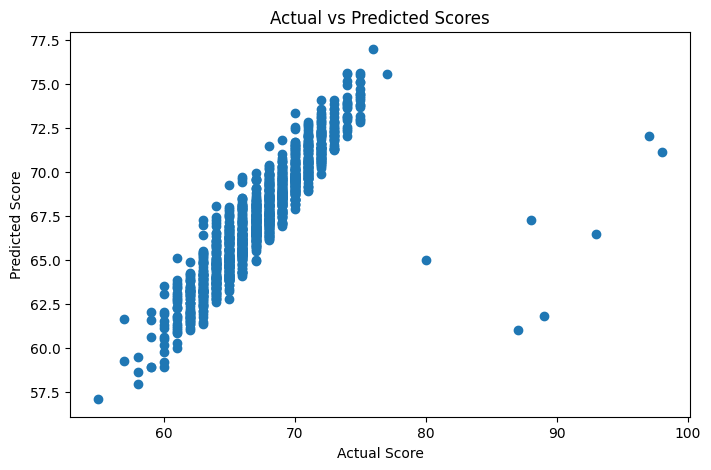

In [629]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title(
    "Actual vs Predicted Scores"
)

plt.show()

In [630]:
# Model 2: Random Forest Regressor (Comparison Model)

In [631]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [632]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Random Forest Results")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_predictions
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        rf_predictions
    )
)

Random Forest Results
MAE: 1.1313993948562784
MSE: 4.881689031770046
R2 Score: 0.6546399715264632


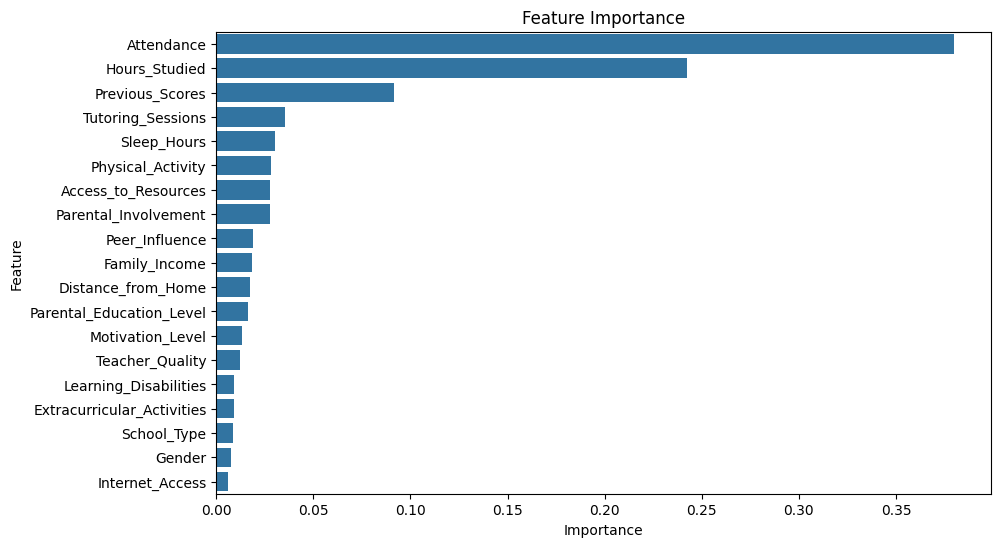

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title(
    "Feature Importance"
)


plt.savefig(
    "../images/Teacher Quality vs Exam Score.png",
         bbox_inches="tight"
)

plt.show()

In [634]:
import pickle

with open("../models/student_performance_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model Saved Successfully")

Model Saved Successfully


In [635]:
# Feature Correlation with Target

correlation_with_target = numeric_df.corr()["Exam_Score"]\
    .sort_values(ascending=False)

print(correlation_with_target)

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [636]:
print(feature_importance.head(10))

                 Feature  Importance
1             Attendance    0.380088
0          Hours_Studied    0.242312
6        Previous_Scores    0.091586
9      Tutoring_Sessions    0.035263
5            Sleep_Hours    0.030049
14     Physical_Activity    0.028412
3    Access_to_Resources    0.027855
2   Parental_Involvement    0.027454
13        Peer_Influence    0.018911
10         Family_Income    0.018383


In [637]:
print("Linear Regression Results")
print("-------------------------")
print("MAE :", mean_absolute_error(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))
print("R2  :", r2_score(y_test, predictions))

print("\nRandom Forest Results")
print("-------------------------")
print("MAE :", mean_absolute_error(y_test, rf_predictions))
print("MSE :", mean_squared_error(y_test, rf_predictions))
print("R2  :", r2_score(y_test, rf_predictions))

Linear Regression Results
-------------------------
MAE : 1.0155490830845968
MSE : 4.399275539170952
R2  : 0.6887688020307758

Random Forest Results
-------------------------
MAE : 1.1313993948562784
MSE : 4.881689031770046
R2  : 0.6546399715264632
